# Iterative scipy minimize fitting tutorial: broadband non-MBI filters

This notebook is a tutorial version of the broadband single-filter scipy-minimize notebooks. It covers the non-MBI/IPOL filters from the 2023-09-14 processed table:

- `625-50`
- `675-50`
- `725-50`
- `750-50`
- `775-50`

These are the broadband 625, 675, 725, 750, and 775 nm filters in the processed CSV naming convention. This tutorial also fits an IMR offset angle as `image_rotator.delta_theta`, following the existing `with_IMR_offset` notebooks. The fitting mechanics are the same as the parent notebooks: load data, load a previous fit as `p0`, build a system Mueller matrix, minimize, update `p0`, and iterate until the likelihood change is small.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (path / "instruments.py").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Run this notebook from inside the cloned vampires_calibration repository.")

sys.path.insert(0, str(REPO_ROOT))
print(f"Using vampires_calibration repo: {REPO_ROOT}")

import instruments as inst
import numpy as np
import pandas as pd
import json

Using vampires_calibration repo: /home/rebeccaz/Github/vampires_calibration


## Input CSV format for broadband fitting

For broadband/IPOL filters, call `inst.read_csv` with `obs_mode="IPOL"` and `obs_filter` set to the `FILTER01` value, such as `625-50` or `775-50`.

Required columns:

| column | meaning |
| --- | --- |
| `OBS-MOD` | Observation mode. These rows are usually `IPOL`. |
| `FILTER01` | Filter name, for example `625-50` or `775-50`. |
| `RET-POS1` | HWP angle for that exposure, in degrees. |
| `D_IMRANG` | Image rotator angle, in degrees. |
| `U_FLC` | FLC state label. `A` maps to `flc_a_theta`; `B` maps to `flc_b_theta`. |
| `diff`, `sum` | Scalar single-difference and single-sum measured values. |
| `diff_std`, `sum_std` | Scalar uncertainties for `diff` and `sum`. |

`read_csv` returns interleaved values `[diff0, sum0, diff1, sum1, ...]`, matching interleaved uncertainties, and one configuration dictionary per row.

In [ ]:
# NOTE: Can change this data path for another .csv
broadband_file_path = REPO_ROOT / "data" / "20230914_processed_table.csv"
# NOTE: Can change this fit directory in order to use different starting guesses for the tutorial
initial_fits_directory = REPO_ROOT / "scipy_minimize" / "data_files" / "initial"
# NOTE: Can change this to where the saved fits files will be
produced_fits_directory = REPO_ROOT / "scipy_minimize" / "data_files" / "produced"

# Tutorial outputs go into their own directory so running this notebook does not overwrite
# the existing fit products used by other notebooks.
save_fits_directory = produced_fits_directory / "tutorials" / "broadband_iterative_scipy_minimize"
save_fits_directory.mkdir(parents=True, exist_ok=True)

wavelengths = ["625-50", "675-50", "725-50", "750-50", "775-50"]
obs_mode = "IPOL"

# Use no EM-gain correction in this tutorial.
em_gains = [1.0] * len(wavelengths)


def starting_fit_path(wavelength):
    return initial_fits_directory / f"{wavelength}nm.txt"


def output_prefix(wavelength):
    return f"{wavelength}nm_no_IMR_offset_or_IMR_and_HWP_constraints_tutorial"


pd.DataFrame(
    {
        "wavelength": wavelengths,
        "obs_mode": [obs_mode] * len(wavelengths),
        "em_gain": em_gains,
        "starting_fit": [starting_fit_path(wavelength) for wavelength in wavelengths],
        "output_prefix": [output_prefix(wavelength) for wavelength in wavelengths],
    }
)

,wavelength,obs_mode,em_gain,starting_fit,output_prefix
0,625-50,IPOL,1.0,/home/rebeccaz/Github/vampires_calibration/sci...,625-50nm_no_IMR_offset_or_IMR_and_HWP_constrai...
1,675-50,IPOL,1.0,/home/rebeccaz/Github/vampires_calibration/sci...,675-50nm_no_IMR_offset_or_IMR_and_HWP_constrai...
2,725-50,IPOL,1.0,/home/rebeccaz/Github/vampires_calibration/sci...,725-50nm_no_IMR_offset_or_IMR_and_HWP_constrai...
3,750-50,IPOL,1.0,/home/rebeccaz/Github/vampires_calibration/sci...,750-50nm_no_IMR_offset_or_IMR_and_HWP_constrai...
4,775-50,IPOL,1.0,/home/rebeccaz/Github/vampires_calibration/sci...,775-50nm_no_IMR_offset_or_IMR_and_HWP_constrai...


## Quick sanity check: raw rows and parsed arrays

These previews help catch common setup mistakes: using the wrong `FILTER01` label, or missing `diff_std`/`sum_std`. For these broadband filters, `diff_std` and `sum_std` should each be one number per row.

In [3]:
broadband_raw = pd.read_csv(broadband_file_path)
broadband_columns = ["OBS-MOD", "FILTER01", "RET-POS1", "D_IMRANG", "U_FLC", "diff", "diff_std", "sum", "sum_std"]

print("Available broadband rows by FILTER01:")
print(broadband_raw[broadband_raw["OBS-MOD"].eq("IPOL")]["FILTER01"].value_counts().sort_index())

print("\nBroadband/IPOL example rows:")
print(
    broadband_raw[broadband_raw["FILTER01"].eq(wavelengths[0])][broadband_columns]
    .head(6)
    .to_string(index=False)
)

sample_wavelength = wavelengths[0]
interleaved_values, interleaved_stds, configuration_list = inst.read_csv(
    broadband_file_path,
    obs_mode=obs_mode,
    obs_filter=sample_wavelength,
    flc_a_theta=0,
    flc_b_theta=45,
)

print(f"\nParsed sample wavelength: {sample_wavelength}")
print(f"interleaved_values shape: {np.shape(interleaved_values)}")
print(f"interleaved_stds shape: {np.shape(interleaved_stds)}")
print(f"configuration_list length: {len(configuration_list)}")
print("First three parsed configurations:")
for config in configuration_list[:3]:
    print(config)

Available broadband rows by FILTER01:
FILTER01
625-50    160
675-50    160
725-50    160
750-50    160
775-50    160
Open      160
Name: count, dtype: int64

Broadband/IPOL example rows:
OBS-MOD FILTER01  RET-POS1  D_IMRANG U_FLC    diff  diff_std    sum   sum_std
   IPOL   625-50       0.0      45.0     A -1080.0  66.22258 1763.5  81.24302
   IPOL   625-50       0.0      45.0     B   636.0 128.18863 1712.0   79.7065
   IPOL   625-50       0.0      57.5     A -1081.0  66.52477 1759.0 82.804184
   IPOL   625-50       0.0      57.5     B   758.0   65.0891 1706.0  80.72938
   IPOL   625-50       0.0      70.0     A -1312.0  71.02066 1774.0 356.43402
   IPOL   625-50       0.0      70.0     B  1125.0  66.99792 1711.0 80.296646

Parsed sample wavelength: 625-50
interleaved_values shape: (320,)
interleaved_stds shape: (320,)
configuration_list length: 160
First three parsed configurations:
{'hwp': {'theta': 0.0}, 'image_rotator': {'theta': 45.0}, 'flc': {'theta': 0}}
{'hwp': {'theta': 0.0}, 

## Starting-fit JSON format

The broadband jobs use the files in `scipy_minimize/data_files/initial/` as starting points.

The JSON format is:

- outer keys are optical components (`dichroic`, `flc`, `optics`, `image_rotator`, `hwp`, and `lp`),
- inner keys are fit parameters,
- `phi` values are in radians,
- `theta` and `delta_theta` values are in degrees,
- `epsilon` values are unitless,
- old starting-fit files may not contain `image_rotator.delta_theta`; this tutorial initializes that IMR offset to `0.0` degrees before fitting.

The order of entries in `p0` matters because `inst.parse_configuration(p0)` turns this dictionary into the vector passed to scipy. Keep `bounds` in the same order.

In [4]:
for sample_wavelength in (wavelengths[0], wavelengths[-1]):
    print("\n" + sample_wavelength)
    print(starting_fit_path(sample_wavelength))
    with open(starting_fit_path(sample_wavelength), "r") as f:
        sample_p0 = json.load(f)
    print(json.dumps(sample_p0, indent=4))


625-50
/home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/initial/625-50nm.txt
{
    "dichroic": {
        "phi": 0.30872304463963207,
        "epsilon": 0.010945621474919988,
        "theta": 1.8315213575483158
    },
    "flc": {
        "phi": 3.318462559843585,
        "delta_theta": 1.798029718547543
    },
    "optics": {
        "phi": -0.8083964583195624,
        "epsilon": 0.013895280106864007,
        "theta": 18.01712022177098
    },
    "image_rotator": {
        "phi": 1.365065666004961
    },
    "hwp": {
        "phi": 2.752521179595714,
        "delta_theta": -1.9748257333612886
    },
    "lp": {
        "theta": -0.15074376412465285
    }
}

775-50
/home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/initial/775-50nm.txt
{
    "dichroic": {
        "phi": -0.4453209230456945,
        "epsilon": 0.22985493763100695,
        "theta": 19.817421224767727
    },
    "flc": {
        "phi": 3.530192368576989,
        "delta_theta": 4.99759

## Bounds

These broadband jobs use the broad bounds from `fixed_EM_gain_no_retardance_restrictions/all_wavelengths_no_IMR_offset_or_IMR_and_HWP_retardance_constraints.ipynb`, with the IMR offset-angle bound added from the existing `with_IMR_offset` notebooks.

In [5]:
def broadband_bounds():
    return [
        (0, 2 * np.pi),  # dichroic phi
        (0, 1),  # dichroic epsilon
        (-90, 90),  # dichroic theta
        (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # FLC phi
        (-5, 5),  # FLC delta_theta
        (0, 2 * np.pi),  # optics phi
        (0, 1),  # optics epsilon
        (-90, 90),  # optics theta
        (0, 2 * np.pi),  # image rotator phi
        (-1, 1),  # image rotator delta_theta / IMR offset angle
        (0, 2 * np.pi),  # HWP phi
        (-5, 5),  # HWP delta_theta
        (-5, 5),  # LP theta
    ]

## Fit each broadband filter iteratively

This is the same iterative structure as the parent notebooks, using a simple wavelength list so the five broadband filters can live in one tutorial. Outputs are written to the tutorial output directory defined above.


Fitting 625-50 (IPOL)
Initial logl value: 6113.088296954005


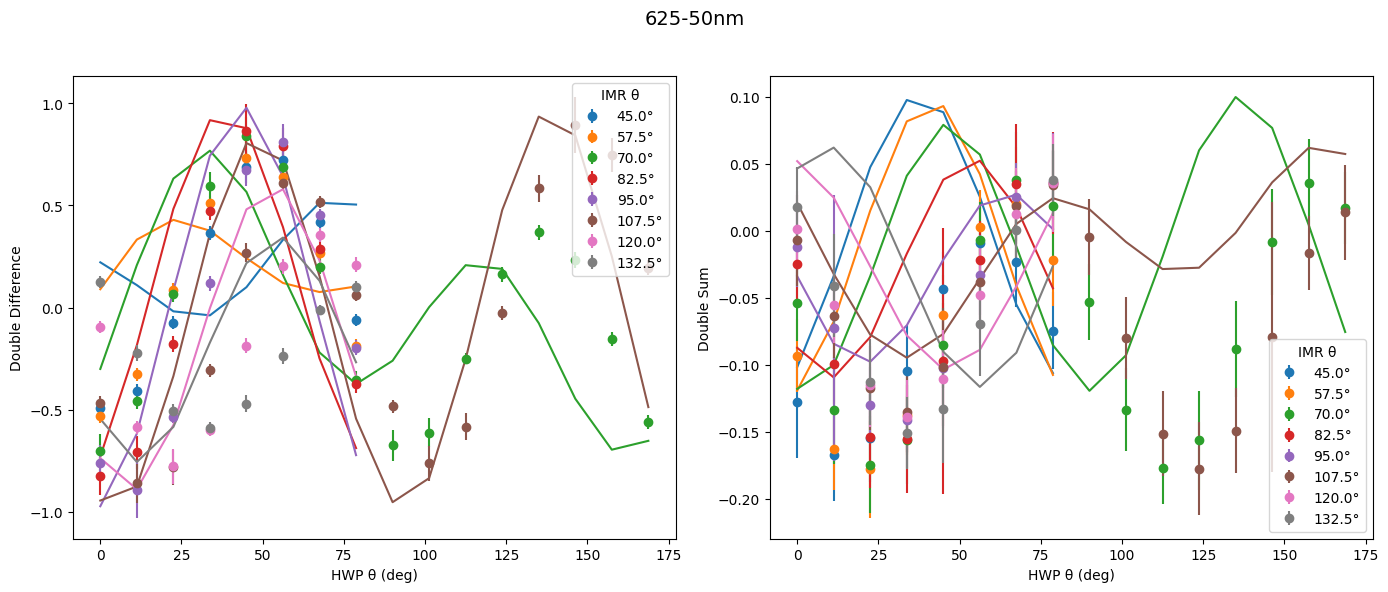

Before p0: {'dichroic': {'phi': 0.30872304463963207, 'epsilon': 0.010945621474919988, 'theta': 1.8315213575483158}, 'flc': {'phi': 3.318462559843585, 'delta_theta': 1.798029718547543}, 'optics': {'phi': 0.8083964583195624, 'epsilon': 0.013895280106864007, 'theta': 18.01712022177098}, 'image_rotator': {'phi': 1.365065666004961, 'delta_theta': 0.0}, 'hwp': {'phi': 2.752521179595714, 'delta_theta': -1.9748257333612886}, 'lp': {'theta': -0.15074376412465285}}
Iteration #: 1
logl_value: 28.833601844085905
Best Fit Parameters: [ 7.58302531e-01  7.55286763e-02 -1.34905002e+01  3.76991118e+00
  1.10699081e-01  6.04202111e-01  3.26098039e-02 -2.55365640e+01
  1.36825963e+00 -3.42457260e-03  2.76329866e+00 -2.01618603e+00
 -2.59128593e-04]


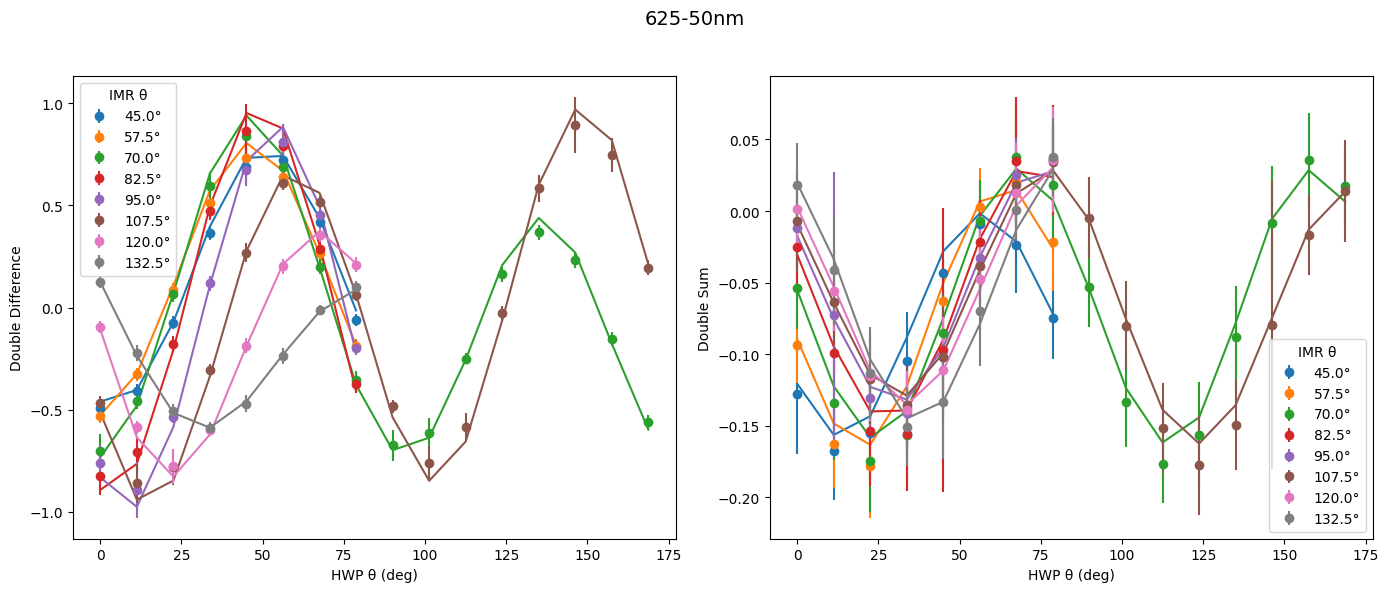

After p0: {'dichroic': {'phi': 0.7583025314423857, 'epsilon': 0.07552867634157398, 'theta': -13.490500221422304}, 'flc': {'phi': 3.7699111843077517, 'delta_theta': 0.11069908146840858}, 'optics': {'phi': 0.6042021106389769, 'epsilon': 0.03260980385934809, 'theta': -25.536563959630666}, 'image_rotator': {'phi': 1.3682596255387665, 'delta_theta': -0.0034245725973165667}, 'hwp': {'phi': 2.763298658582572, 'delta_theta': -2.0161860325214964}, 'lp': {'theta': -0.0002591285925689613}}
Before p0: {'dichroic': {'phi': 0.7583025314423857, 'epsilon': 0.07552867634157398, 'theta': -13.490500221422304}, 'flc': {'phi': 3.7699111843077517, 'delta_theta': 0.11069908146840858}, 'optics': {'phi': 0.6042021106389769, 'epsilon': 0.03260980385934809, 'theta': -25.536563959630666}, 'image_rotator': {'phi': 1.3682596255387665, 'delta_theta': -0.0034245725973165667}, 'hwp': {'phi': 2.763298658582572, 'delta_theta': -2.0161860325214964}, 'lp': {'theta': -0.0002591285925689613}}
Iteration #: 2
logl_value: 27.7

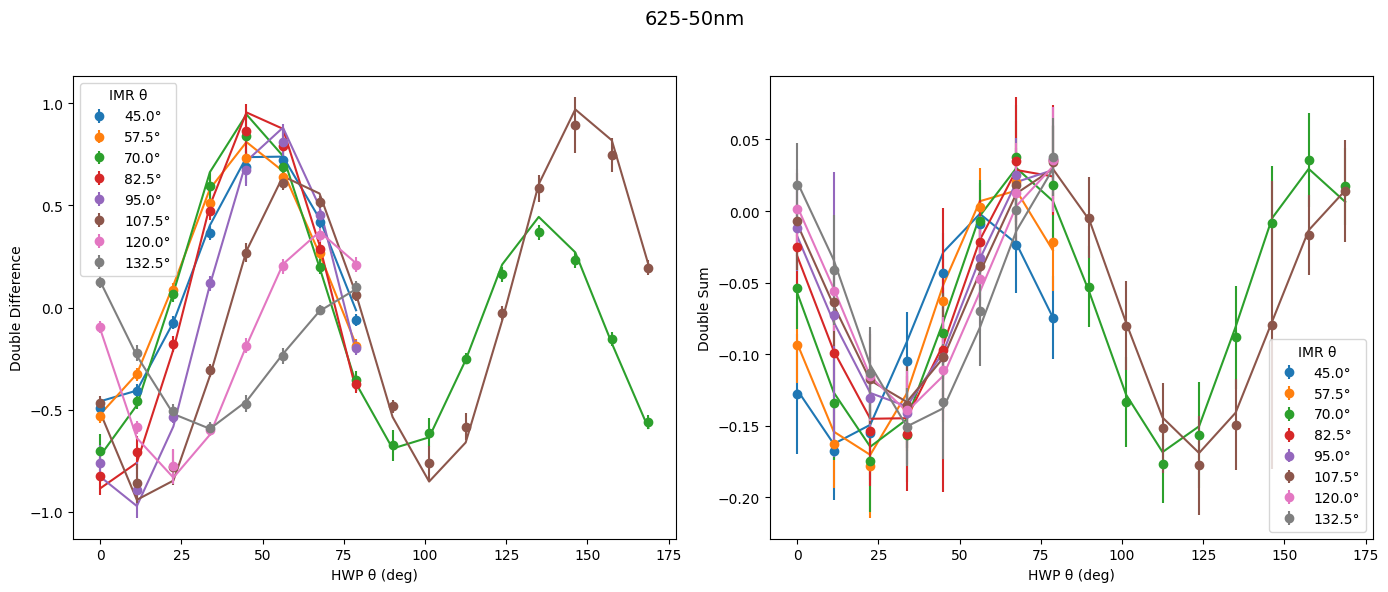

After p0: {'dichroic': {'phi': 1.4866603615729526, 'epsilon': 0.07468820139527818, 'theta': -9.427614952909622}, 'flc': {'phi': 3.7699111843077517, 'delta_theta': -2.396417386214331}, 'optics': {'phi': 0.5292109779325209, 'epsilon': 0.049702883537889264, 'theta': -31.19151807803493}, 'image_rotator': {'phi': 1.3689943201200139, 'delta_theta': -0.057464410105642114}, 'hwp': {'phi': 2.7631842576375973, 'delta_theta': -2.015555330884765}, 'lp': {'theta': 0.001707698294160421}}
Before p0: {'dichroic': {'phi': 1.4866603615729526, 'epsilon': 0.07468820139527818, 'theta': -9.427614952909622}, 'flc': {'phi': 3.7699111843077517, 'delta_theta': -2.396417386214331}, 'optics': {'phi': 0.5292109779325209, 'epsilon': 0.049702883537889264, 'theta': -31.19151807803493}, 'image_rotator': {'phi': 1.3689943201200139, 'delta_theta': -0.057464410105642114}, 'hwp': {'phi': 2.7631842576375973, 'delta_theta': -2.015555330884765}, 'lp': {'theta': 0.001707698294160421}}
Iteration #: 3
logl_value: 27.58385307936

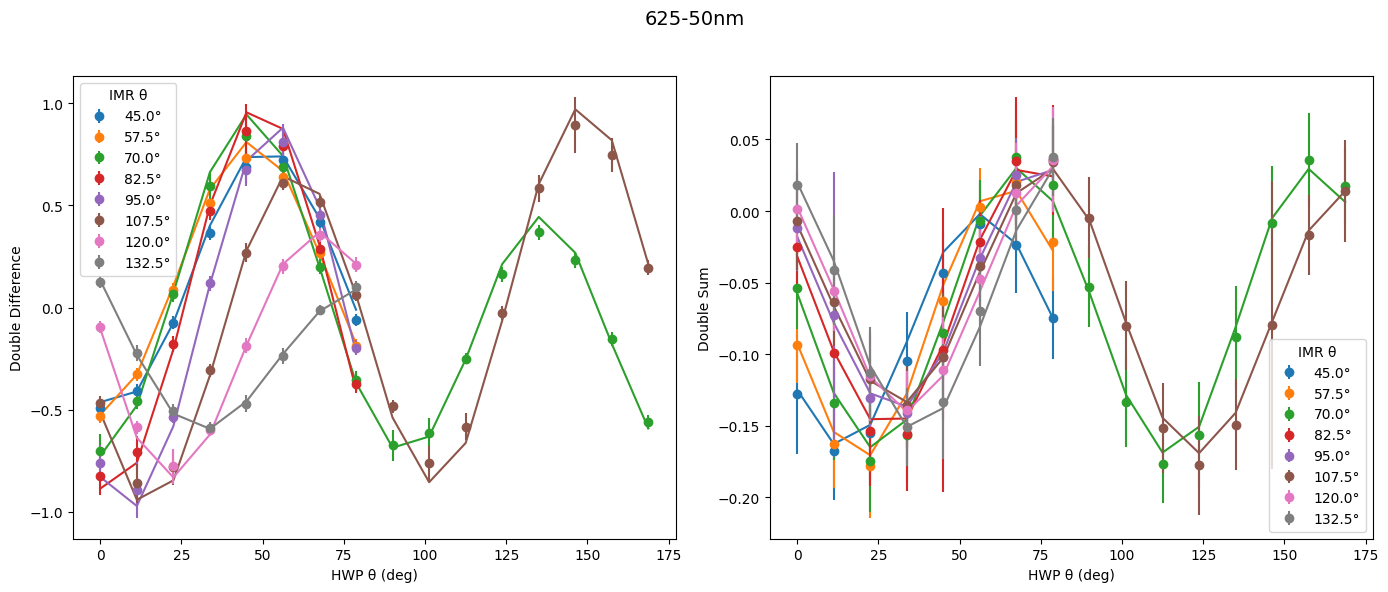

After p0: {'dichroic': {'phi': 1.5420109482155933, 'epsilon': 0.07473757615818732, 'theta': -9.356284897250356}, 'flc': {'phi': 3.7699111843077517, 'delta_theta': -2.9980572344064416}, 'optics': {'phi': 0.5305353008277619, 'epsilon': 0.05078281287656296, 'theta': -32.21643056823178}, 'image_rotator': {'phi': 1.3697494525158123, 'delta_theta': -0.8209493279920197}, 'hwp': {'phi': 2.763185051739907, 'delta_theta': -2.35592575841428}, 'lp': {'theta': -0.0004454827239165107}}
Before p0: {'dichroic': {'phi': 1.5420109482155933, 'epsilon': 0.07473757615818732, 'theta': -9.356284897250356}, 'flc': {'phi': 3.7699111843077517, 'delta_theta': -2.9980572344064416}, 'optics': {'phi': 0.5305353008277619, 'epsilon': 0.05078281287656296, 'theta': -32.21643056823178}, 'image_rotator': {'phi': 1.3697494525158123, 'delta_theta': -0.8209493279920197}, 'hwp': {'phi': 2.763185051739907, 'delta_theta': -2.35592575841428}, 'lp': {'theta': -0.0004454827239165107}}


KeyboardInterrupt: 

In [6]:
convergence_fraction = 0.001
max_iterations = 50

for i, wavelength in enumerate(wavelengths):
    print("\n" + "=" * 80)
    print(f"Fitting {wavelength} ({obs_mode})")

    interleaved_values, interleaved_stds, configuration_list = inst.read_csv(
        broadband_file_path,
        obs_mode=obs_mode,
        obs_filter=wavelength,
        flc_a_theta=0,
        flc_b_theta=45,
    )

    with open(starting_fit_path(wavelength), "r") as f:
        past_fit = json.load(f)
    past_fit.setdefault("image_rotator", {})
    past_fit["image_rotator"].setdefault("delta_theta", 0.0)

    theta_pol = past_fit["lp"]["theta"]
    delta_HWP = past_fit["hwp"]["phi"]
    offset_HWP = past_fit["hwp"]["delta_theta"]
    delta_derot = past_fit["image_rotator"]["phi"]
    offset_derot = past_fit["image_rotator"]["delta_theta"]
    delta_opts = past_fit["optics"]["phi"]
    epsilon_opts = past_fit["optics"]["epsilon"]
    rot_opts = past_fit["optics"]["theta"]
    delta_dichroic = past_fit["dichroic"]["phi"]
    epsilon_dichroic = past_fit["dichroic"]["epsilon"]
    rot_dichroic = past_fit["dichroic"]["theta"]
    delta_FLC = past_fit["flc"]["phi"]
    rot_FLC = past_fit["flc"]["delta_theta"]
    em_gain = em_gains[i]

    # NOTE: Components must be listed downstream to upstream.
    system_dict = {
        "components": {
            "wollaston": {
                "type": "wollaston_prism_function",
                "properties": {"beam": "o", "transmission_ratio": em_gain},
            },
            "dichroic": {
                "type": "diattenuator_retarder_function",
                "properties": {
                    "phi": delta_dichroic,
                    "epsilon": epsilon_dichroic,
                    "theta": rot_dichroic,
                },
            },
            "flc": {
                "type": "general_retarder_function",
                "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
            },
            "optics": {
                "type": "diattenuator_retarder_function",
                "properties": {
                    "phi": delta_opts,
                    "epsilon": epsilon_opts,
                    "theta": rot_opts,
                },
            },
            "image_rotator": {
                "type": "general_retarder_function",
                "properties": {"phi": delta_derot, "theta": 0, "delta_theta": offset_derot},
            },
            "hwp": {
                "type": "general_retarder_function",
                "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
            },
            "lp": {
                "type": "general_linear_polarizer_function_with_theta",
                "properties": {"theta": theta_pol},
            },
        }
    }

    bounds = broadband_bounds()
    system_mm = inst.generate_system_mueller_matrix(system_dict)

    p0 = {
        "dichroic": {
            "phi": np.abs(delta_dichroic),
            "epsilon": epsilon_dichroic,
            "theta": rot_dichroic,
        },
        "flc": {"phi": delta_FLC, "delta_theta": rot_FLC},
        "optics": {
            "phi": np.abs(delta_opts),
            "epsilon": epsilon_opts,
            "theta": rot_opts,
        },
        "image_rotator": {"phi": delta_derot, "delta_theta": offset_derot},
        "hwp": {"phi": delta_HWP, "delta_theta": offset_HWP},
        "lp": {"theta": theta_pol},
    }

    p0_values, p0_keywords = inst.parse_configuration(p0)
    s_in = np.array([1, 0, 0, 0])

    logl_value = inst.logl(
        p0_values,
        p0_keywords,
        system_mm,
        interleaved_values,
        interleaved_stds,
        configuration_list,
        s_in=s_in,
        logl_function=None,
        process_dataset=inst.process_dataset,
        process_errors=inst.process_errors,
        process_model=inst.process_model,
    )
    print("Initial logl value:", logl_value)

    model = inst.model(
        p0_values,
        p0_keywords,
        system_mm,
        configuration_list,
        process_model=inst.process_model,
    )
    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, configuration_list, wavelength=wavelength)

    iteration = 1
    previous_logl_value = 1000000
    new_logl_value = 0

    while (
        abs(previous_logl_value - new_logl_value)
        > convergence_fraction * abs(previous_logl_value)
        and iteration <= max_iterations
    ):
        print("Before p0:", p0)
        if iteration > 1:
            previous_logl_value = new_logl_value

        result, new_logl_value = inst.minimize_system_mueller_matrix(
            p0,
            system_mm,
            interleaved_values,
            interleaved_stds,
            configuration_list,
            s_in=s_in,
            process_dataset=inst.process_dataset,
            process_errors=inst.process_errors,
            process_model=inst.process_model,
            bounds=bounds,
        )

        print("Iteration #:", iteration)
        print("logl_value:", new_logl_value)
        print("Best Fit Parameters:", result.x)

        updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
        model = inst.model(
            result.x,
            p0_keywords,
            updated_system_mm,
            configuration_list,
            process_model=inst.process_model,
        )

        save_path = save_fits_directory / f"{output_prefix(wavelength)}.png"
        inst.plot_data_and_model(
            interleaved_values,
            interleaved_stds,
            model,
            configuration_list,
            wavelength=wavelength,
            save_path=save_path,
        )

        inst.update_p0(p0, result.x)
        print("After p0:", p0)

        output_filename = save_fits_directory / f"{output_prefix(wavelength)}.txt"
        with open(output_filename, "w") as f:
            json.dump(p0, f, indent=4)

        iteration += 1

    if iteration > max_iterations:
        print(f"Stopped after max_iterations={max_iterations}; inspect the last saved fit before using it.")

## Summary table

In [7]:
def radians_to_waves(rad):
    return rad / (2 * np.pi)


summary_rows = []
param_names = [
    "wavelength",
    "obs_mode",
    "dichroic_phi (waves)",
    "dichroic_epsilon",
    "dichroic_theta",
    "flc_phi (waves)",
    "flc_delta_theta",
    "optics_phi (waves)",
    "optics_epsilon",
    "optics_theta",
    "image_rotator_phi (waves)",
    "image_rotator_delta_theta",
    "hwp_phi (waves)",
    "hwp_delta_theta",
    "lp_theta",
]

for wavelength in wavelengths:
    filename = save_fits_directory / f"{output_prefix(wavelength)}.txt"
    try:
        with open(filename, "r") as f:
            p0 = json.load(f)
        summary_rows.append(
            {
                "wavelength": wavelength,
                "obs_mode": obs_mode,
                "dichroic_phi (waves)": radians_to_waves(p0["dichroic"]["phi"]),
                "dichroic_epsilon": p0["dichroic"]["epsilon"],
                "dichroic_theta": p0["dichroic"]["theta"],
                "flc_phi (waves)": radians_to_waves(p0["flc"]["phi"]),
                "flc_delta_theta": p0["flc"]["delta_theta"],
                "optics_phi (waves)": radians_to_waves(p0["optics"]["phi"]),
                "optics_epsilon": p0["optics"]["epsilon"],
                "optics_theta": p0["optics"]["theta"],
                "image_rotator_phi (waves)": radians_to_waves(p0["image_rotator"]["phi"]),
                "image_rotator_delta_theta": p0["image_rotator"].get("delta_theta", np.nan),
                "hwp_phi (waves)": radians_to_waves(p0["hwp"]["phi"]),
                "hwp_delta_theta": p0["hwp"]["delta_theta"],
                "lp_theta": p0["lp"]["theta"],
            }
        )
    except Exception as exc:
        print(f"Could not load {filename}: {exc}")

df = pd.DataFrame(summary_rows, columns=param_names)
print("\nSummary of final p0 values for each broadband fit (retardances in waves):")
print(df.to_string(index=False))

Could not load /home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/produced/tutorials/broadband_iterative_scipy_minimize/675-50nm_no_IMR_offset_or_IMR_and_HWP_constraints_tutorial.txt: [Errno 2] No such file or directory: '/home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/produced/tutorials/broadband_iterative_scipy_minimize/675-50nm_no_IMR_offset_or_IMR_and_HWP_constraints_tutorial.txt'
Could not load /home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/produced/tutorials/broadband_iterative_scipy_minimize/725-50nm_no_IMR_offset_or_IMR_and_HWP_constraints_tutorial.txt: [Errno 2] No such file or directory: '/home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/produced/tutorials/broadband_iterative_scipy_minimize/725-50nm_no_IMR_offset_or_IMR_and_HWP_constraints_tutorial.txt'
Could not load /home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/produced/tutorials/broadband_iterative_scipy_minimize/750-50nm